# Heart Failure Prediction

## Project Overview
This project aims to predict heart failure events using a dataset containing various clinical features. The analysis involves data loading, exploratory data analysis (EDA), feature selection, data preprocessing, and training several machine learning classification models. The goal is to identify key factors contributing to heart failure and build predictive models to assist in early detection.

## Dataset
The dataset used in this project is `heart_failure.csv`, which contains 299 observations and 13 features related to heart failure, including:
- `age`: Age of the patient
- `anaemia`: Boolean (0 = no, 1 = yes)
- `creatinine_phosphokinase`: Level of the CPK enzyme in the blood
- `diabetes`: Boolean (0 = no, 1 = yes)
- `ejection_fraction`: Percentage of blood leaving the heart at each contraction
- `high_blood_pressure`: Boolean (0 = no, 1 = yes)
- `platelets`: Platelets in the blood
- `serum_creatinine`: Level of serum creatinine in the blood
- `serum_sodium`: Level of serum sodium in the blood
- `sex`: Binary (0 = female, 1 = male)
- `smoking`: Boolean (0 = no, 1 = yes)
- `time`: Follow-up period (days)
- `DEATH_EVENT`: Target variable (0 = no heart failure, 1 = heart failure)

## Key Steps and Analysis

### 1. Data Loading and Initial Exploration
- Loaded the `heart_failure.csv` dataset using pandas.
- Checked for missing values (`data.isnull().values.any()`) and found none.
- Examined data types and non-null counts using `data.info()`.
- Displayed basic descriptive statistics using `data.describe()`.
- Analyzed the distribution of the target variable `DEATH_EVENT`.

### 2. Data Visualization
- Plotted histograms for all features to understand their distributions (`data.hist()`).
- Explored the relationship between `sex`, `age`, and `DEATH_EVENT` using bar plots.
- Visualized the impact of `platelets`, `serum_creatinine`, and `ejection_fraction` on `DEATH_EVENT` using bar and swarm plots.
- Used `sns.pairplot`, `sns.scatterplot`, and `sns.lmplot` to understand relationships between key features (`age`, `serum_creatinine`, `ejection_fraction`) and the target variable.

### 3. Feature Selection
Three techniques were employed to identify important features:
- **Correlation Matrix with Heatmap**: Visualized correlations between all features and specifically with `DEATH_EVENT`.
- **Univariate Selection (SelectKBest with Chi-squared)**: Identified the top 5 features based on their statistical relationship with the target.
- **Feature Importance (ExtraTreesClassifier)**: Ranked features based on their contribution to the model's accuracy.

Key features identified across these methods include 'serum_creatinine', 'ejection_fraction', 'age', and 'time'.

### 4. Data Preprocessing
- **Train-Test Split**: The dataset was split into training (80%) and testing (20%) sets to evaluate model performance (`train_test_split`).
- **Data Normalization (Min-Max Scalar - commented out)**: Although commented out, the notebook included code snippets for `MinMaxScaler`, indicating an intention for feature scaling.

### 5. Model Training and Evaluation
Several classification algorithms were applied and evaluated based on their accuracy and confusion matrices:

- **Logistic Regression**:
    - Achieved a test accuracy of ~77% with 2 selected features.
    - Achieved a test accuracy of ~80% with all features.
    - Confusion Matrix showed good performance with a low error rate.

- **Support Vector Classifier (SVC)**:
    - Achieved a test accuracy of ~58.33%.
    - The confusion matrix indicated a high number of false negatives, suggesting the model struggled to identify positive cases (heart failure).

- **Decision Tree Classifier**:
    - Achieved a test accuracy of ~73.33% with 2 selected features.
    - Achieved a test accuracy of ~53.33% with all features (unoptimized).
    - Optimized version (with `entropy` criterion and `max_leaf_nodes=10`) achieved a test accuracy of ~76.67%.
    - The optimized confusion matrix showed a reasonable error rate.

- **Random Forest Classifier**:
    - Achieved a test accuracy of ~75%.
    - The confusion matrix showed a low error rate, indicating robust performance.

- **ExtraTrees Classifier**:
    - Achieved a test accuracy of ~78.33%.
    - The confusion matrix highlighted some false positives and false negatives.

- **K-Nearest Neighbors (KNN)**:
    - Tested with various `k` values (1 to 20), with optimal `k=14` or `k=19`.
    - Achieved a test accuracy of ~58.33% for `k=19`.
    - The accuracy was lower compared to other models, potentially due to the relatively small dataset size, as KNN generally performs better with larger datasets.

## Conclusion

The models with higher accuracy were Logistic Regression (80%), ExtraTrees Classifier (78.33%), and Random Forest Classifier (75%). The analysis highlights the importance of features like `serum_creatinine`, `ejection_fraction`, `age`, and `time` in predicting heart failure. The class imbalance in the target variable (more 'not dead' cases) led to better prediction of true negatives across most models. Future work could involve collecting more data, exploring advanced feature engineering, and addressing class imbalance for improved model performance, especially in identifying true positive cases.

In [3]:
from google.colab import files
uploaded = files.upload()


Saving heart_failure.csv to heart_failure (1).csv


##Importing libraries and loading dataset

In [4]:
# apply libraries, algorithms,..
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import plotly.express as px
import plotly.graph_objs as gobj
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2, VarianceThreshold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from mlxtend.plotting import plot_confusion_matrix
from pandas.plotting import scatter_matrix
from plotly.offline import plot, iplot, init_notebook_mode


In [5]:
# upload data
data = pd.read_csv('heart_failure.csv', engine='python')
data.head(7)
#data

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1


## Data Visualization

In [54]:
# Generate descriptive statistics to summarize the central tendency, dispersion, and shape of the dataset's distribution.
import pandas as pd
data = pd.read_csv('heart_failure.csv', engine='python')
data.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [7]:
# In cleaning step, i check if there is any null or missing value.
data.isnull().values.any()       # or : data.isna().sum()

np.False_

In [8]:
data.shape

(299, 13)

In [56]:
# Review data types, non-null counts, and dataset dimensions to ensure data integrity.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


**Distribution of Death Event**

In [10]:
data['DEATH_EVENT'].value_counts()    # 0:not dead / 1:dead

,count
DEATH_EVENT,
0,203
1,96


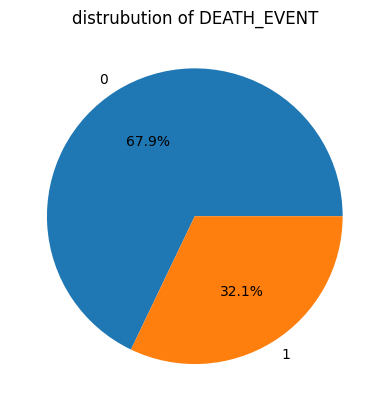

In [11]:
labels = data['DEATH_EVENT'].value_counts().index    # give me the indexes: 0,1
values = data['DEATH_EVENT'].value_counts()
plt.subplot(title='distrubution of DEATH_EVENT' )
plt.pie(values, labels=labels,autopct='%1.1f%%')
plt.show()

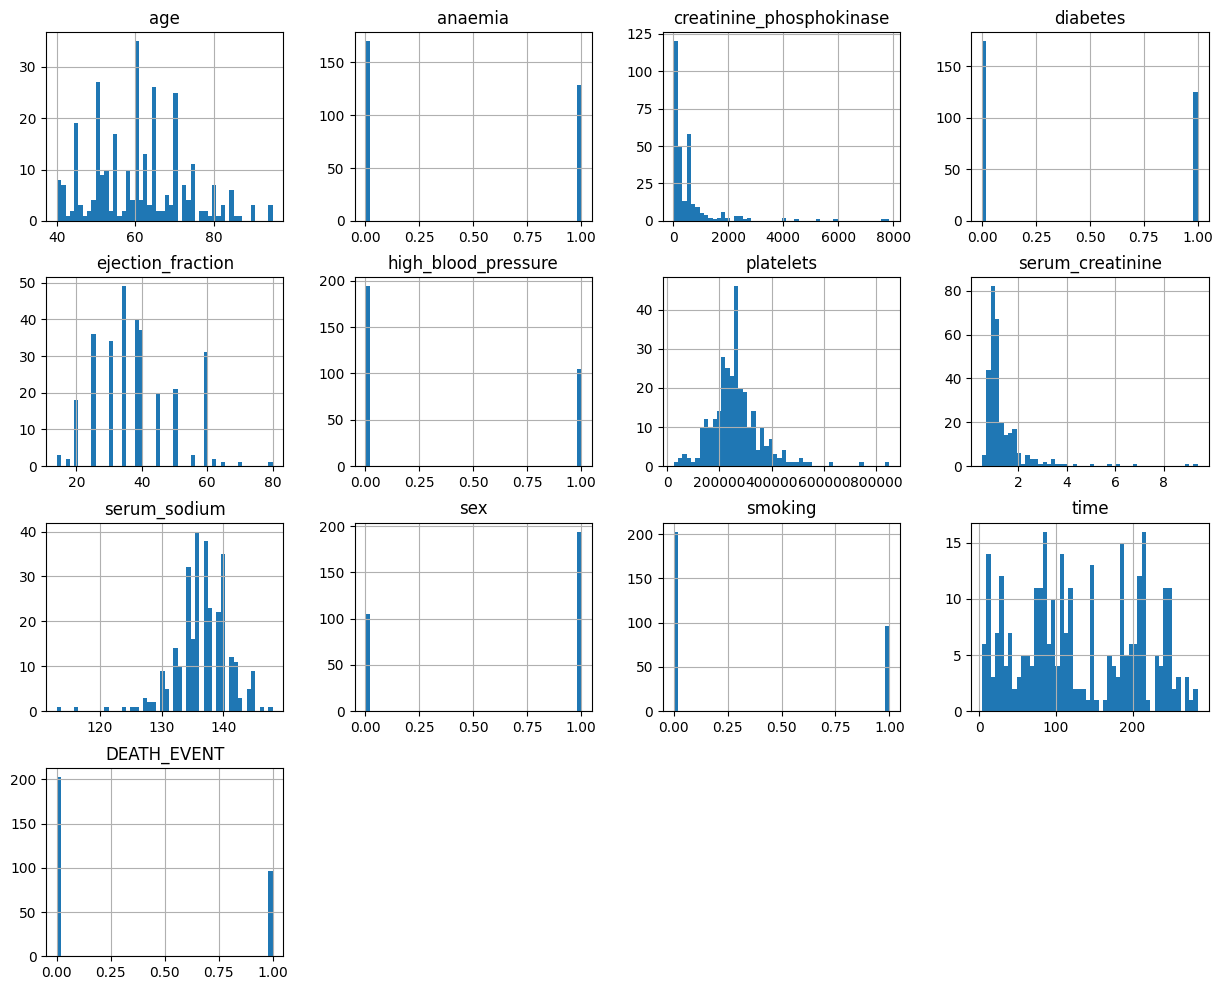

In [12]:
data.hist(bins=50, figsize=(15,12))     # a histogram from my data- using matplotlib
plt.show()

Analysis of the feature distributions indicates that variables with Gaussian-like (bell-shaped) distributions, such as `age` and `ejection_fraction`, may provide more stable signals for certain models. In contrast, features like `creatinine_phosphokinase` exhibit heavy-tailed or highly skewed distributions, which may require further investigation or transformation. However, initial visualization alone is insufficient for final feature selection.

### **Demographic Analysis: Mortality by Age and Sex**
To further evaluate risk factors, we analyze the distribution of mortality ('DEATH_EVENT') across different age groups and biological sexes. Preliminary observation suggests that the incidence of heart failure is relatively balanced between females (0) and males (1), though age serves as a significant continuous variable in these distributions.

<Axes: xlabel='sex', ylabel='age'>

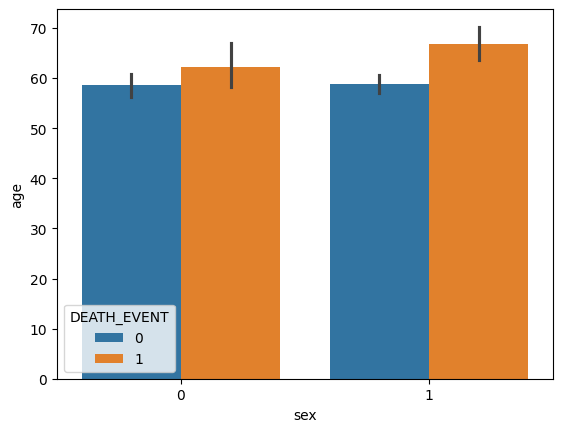

In [13]:
sns.barplot(x='sex', y='age', hue='DEATH_EVENT', data=data)     # 0:femail- 1:male    (1: dead)

### **Feature Exploration: Key Clinical Indicators**
Following the initial overview, we perform targeted visualizations on specific clinical features—such as `platelets` and `serum_creatinine`—that are hypothesized to be significant predictors of mortality events.

<Axes: xlabel='DEATH_EVENT', ylabel='platelets'>

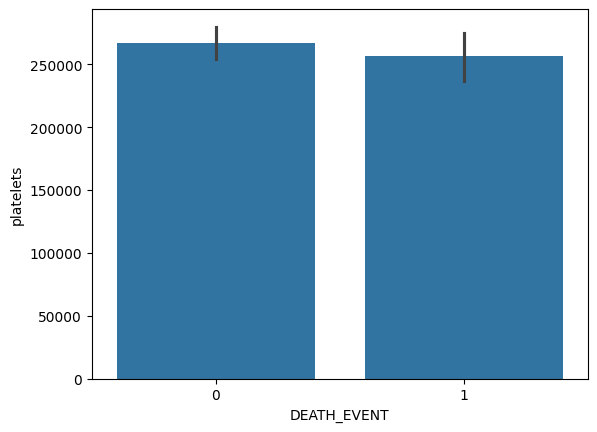

In [58]:
# Explore the relationship between platelet count and the target mortality event.
# Observation: Platelets do not show a significant individual effect on the death event.
sns.barplot(x='DEATH_EVENT', y='platelets', data=data)

### **Feature Exploration: Serum Creatinine**
In the following analysis, we examine the effect of `serum_creatinine`. Unlike platelets, this clinical indicator shows a more pronounced relationship with mortality events in our dataset.

<Axes: xlabel='DEATH_EVENT', ylabel='serum_creatinine'>

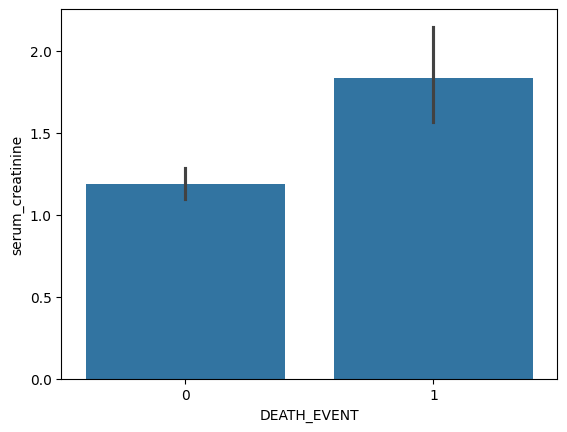

In [59]:

sns.barplot(x='DEATH_EVENT', y='serum_creatinine', data=data)

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

5.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



<Axes: xlabel='DEATH_EVENT', ylabel='serum_creatinine'>

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

33.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



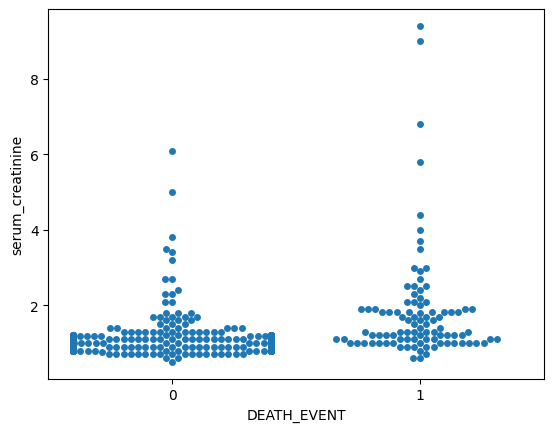

In [16]:
sns.swarmplot(x=data['DEATH_EVENT'], y=data['serum_creatinine'])

<Axes: xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

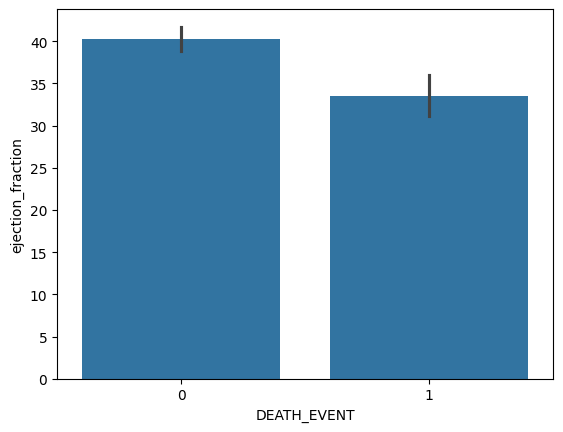

In [17]:
sns.barplot(x='DEATH_EVENT', y='ejection_fraction', data=data)

Analysis of the data reveals that `ejection_fraction` has a notable impact on the target variable. Specifically, lower ejection fraction values are associated with a higher incidence of mortality events, highlighting its importance as a clinical predictor.

#**Pre_processing**
### **Selecting the target and features of data** (Seperating lable and all other features)

In [18]:
feature_cols = []
 for col in data.columns:
     feature_cols.append(col)
 feature_cols.pop(12)
 print(feature_cols)
 x = data[feature_cols]    # feature
 y = data.DEATH_EVENT      # target variable

#x = data.iloc[:,:-1].values
#y= data.iloc[:,-1].values

['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']


In [19]:
#x.shape
#y.shape

# **Feature Selection**

Feature selection is a critical step, especially in high-dimensional datasets, to identify the most relevant predictors and reduce model complexity. By excluding less informative features, we can improve model interpretability and reduce the risk of overfitting.

In this analysis, we employ three different techniques to identify the most significant clinical indicators. We will then compare model performance when using these selected features versus the full dataset to determine which approach yields higher precision.

### **Feature Selection Techniques:**
1.  **Correlation Matrix with Heatmap**: To visualize the linear relationships between features and the target variable.
2.  **Univariate Selection (SelectKBest)**: To select features based on statistical scores (Chi-squared test).
3.  **Feature Importance (Tree-based)**: Using the `ExtraTreesClassifier` to rank features based on their importance to the model's accuracy.

#### **1. Correlation Matrix Analysis**
### **a. Inter-feature Correlation Analysis**
We first calculate the correlation coefficients between all features in the dataset to visualize the internal relationships and identify potential multicollinearity.

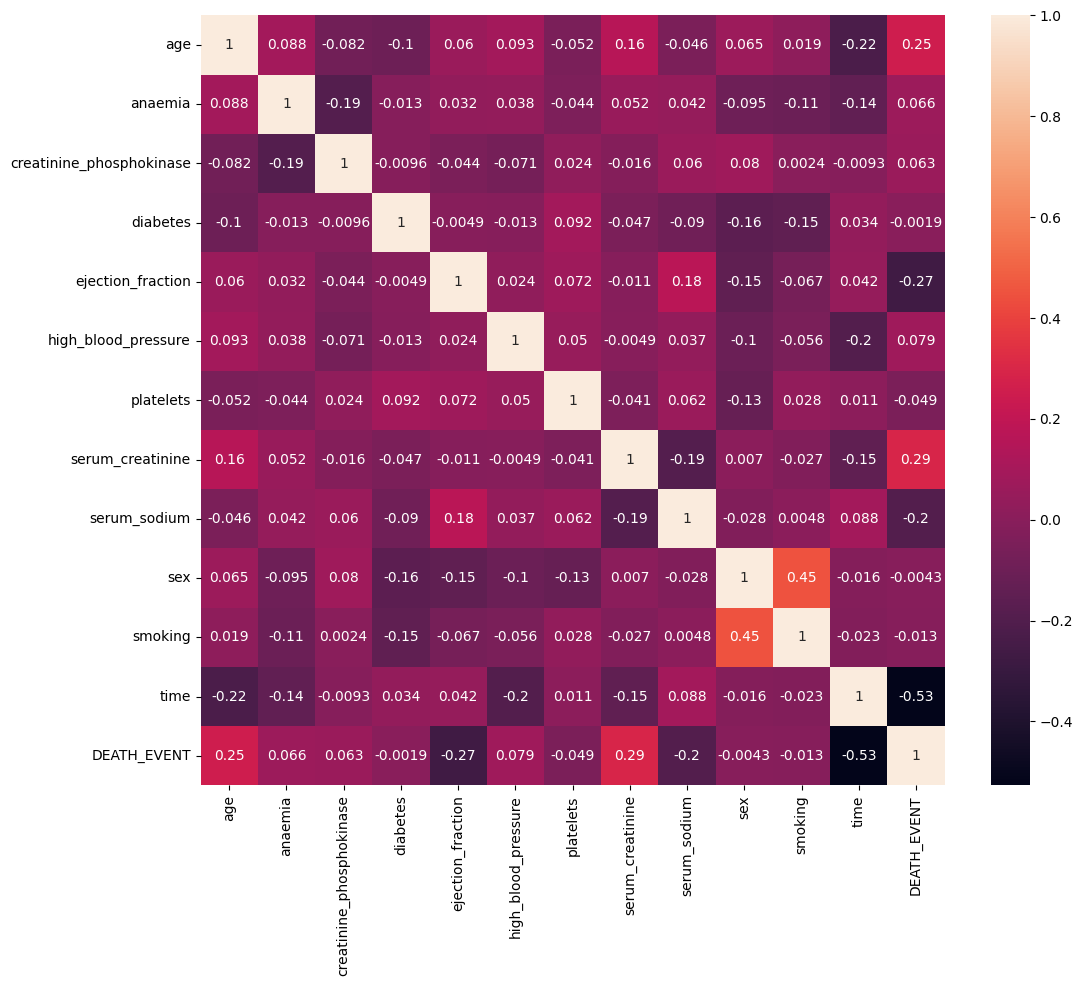

In [20]:
corr_matrix= data.corr()
corr_features = corr_matrix.index
plt.figure(figsize=(12,10))
g= sns.heatmap(data[corr_features].corr(), annot= True)  # annot= True: this ensures that the values for each cell appear on the chart (if no, removes the numbers from each of the cells)

This analysis utilizes the **Pearson correlation coefficient**, which ranges from **-1 to 1**:

*   **Positive Correlation (approaching 1):** Indicates a strong direct relationship; as one feature increases, the other tends to increase.
*   **Negative Correlation (approaching -1):** Indicates a strong inverse relationship; as one feature increases, the other tends to decrease. Both positive and negative correlations are valuable for predictive modeling.
*   **No Correlation (approaching 0):** Indicates a weak or non-existent linear relationship between the variables.

The diagonal of the matrix represents each feature's correlation with itself, which is always 1.0.

### **b. Bivariate Correlation: Feature Alignment with DEATH_EVENT**
This section evaluates the linear relationship between each individual feature and the target variable, identifying which clinical indicators possess the strongest predictive potential for mortality events.

In [21]:
# death:1 /not death:0
corr_matrix = data.corr()
corr_matrix["DEATH_EVENT"].sort_values(ascending=False)

,DEATH_EVENT
DEATH_EVENT,1.000000
serum_creatinine,0.294278
age,0.253729
high_blood_pressure,0.079351
anaemia,0.066270
creatinine_phosphokinase,0.062728
diabetes,-0.001943
sex,-0.004316
smoking,-0.012623
platelets,-0.049139


### **Correlation Analysis Results**

This list highlights the correlation of the target variable with other clinical features. Based on these results, I selected features with a correlation magnitude of approximately **0.25 or higher**:

*   **`serum_creatinine`**: 0.29 (Positive correlation)
*   **`age`**: 0.25 (Positive correlation)
*   **`ejection_fraction`**: -0.27 (Negative correlation)
*   **`time`**: -0.53 (Strong negative correlation)

**Interpretation:**
Values approaching **1** indicate a strong direct relationship, while values approaching **-1** indicate a strong inverse (negative) relationship. Both are valuable for prediction. Conversely, values closer to **0** suggest a weak or non-existent linear relationship with the target variable.

#### **2- UNIVARIANT SELECTION:** applying **SelectKBest** to extract top 5 best features

In [22]:
bestF= SelectKBest(score_func=chi2, k=4)
fit=bestF.fit(x,y)                  # x:feature, y:target variable
dfscores= pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(x.columns)
#concat 2 data frame, i want have a visualization like a table
featureScores= pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns=['Features', 'Scores'] # named the new dataframe columns
print(featureScores.nlargest(5,'Scores'))

                    Features        Scores
6                  platelets  26135.771990
11                      time   3826.892661
2   creatinine_phosphokinase   1897.314839
4          ejection_fraction     79.072541
0                        age     44.619455


### **3- FEATURE IMPORTANCE:**  Tree Based Classifiers

[0.09089332 0.02694727 0.07632059 0.02976266 0.12752807 0.02295438
 0.0731229  0.11579524 0.0855973  0.02588463 0.02752694 0.29766671]


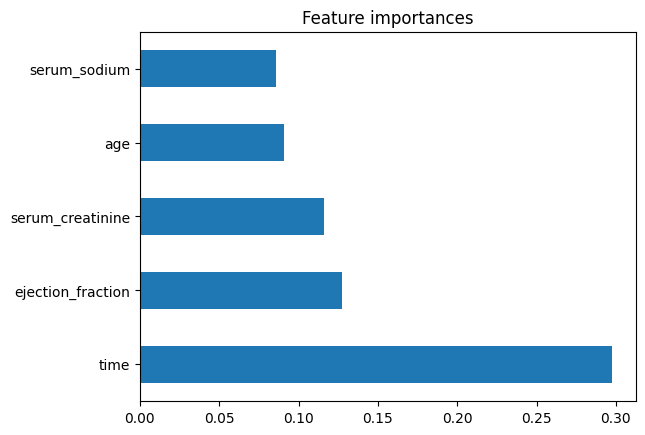

In [23]:
model = ExtraTreesClassifier()
model.fit(x,y)
print(model.feature_importances_)
#plot graph of feature importances for better visualization
plt.title("Feature importances")
feat_importances = pd.Series(model.feature_importances_, index=x.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.show()

### **Synthesis of Feature Selection Results**

By synthesizing the results from the correlation matrix, univariate selection, and tree-based feature importance, we identify **`serum_creatinine`**, **`ejection_fraction`**, **`age`**, and **`time`** as the most significant predictors in our dataset.

**Note on the 'time' feature:**
While `time` (the follow-up period) shows the strongest statistical relationship with the target, it represents data collected *after* clinical monitoring has begun. In a real-world scenario where a model must predict outcomes for a new patient at the moment of admission, this information would be unavailable. However, given its critical importance as a factor in patient survival within this specific dataset, it has been retained for analysis rather than eliminated.

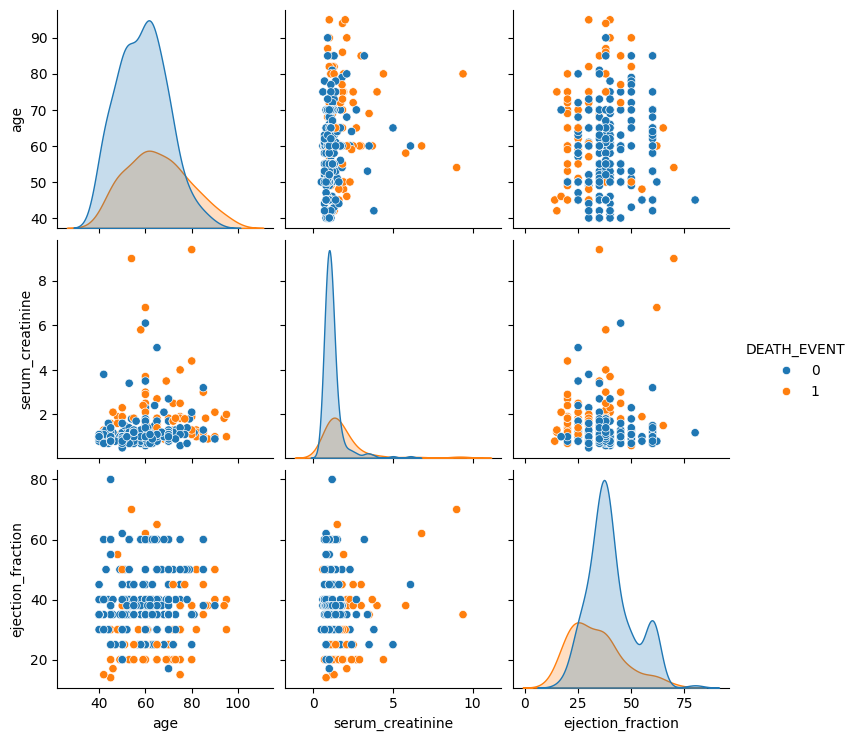

In [24]:
sns.pairplot(data, hue = 'DEATH_EVENT', vars = ['age', 'serum_creatinine', 'ejection_fraction'] )    # 0:not dead / 1:dead

### **Multivariate Analysis: Inter-feature Relationships**
In this section, I conduct a more detailed examination of the relationships between the three most significant clinical predictors to identify any multi-dimensional patterns related to mortality events.

Text(0.5, 0.98, 'Scatterplot of serum creatinine versus ejection fraction')

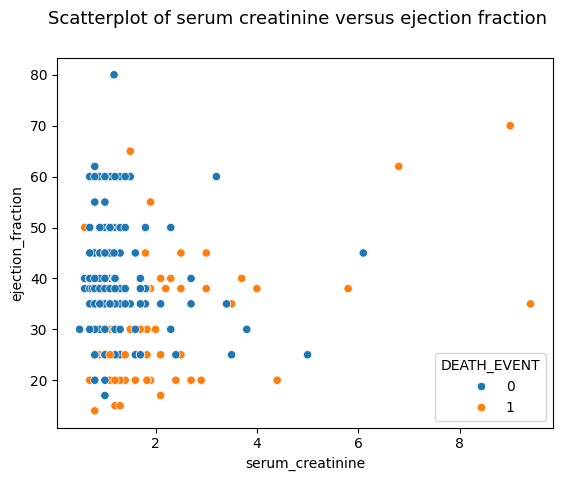

In [25]:
sns.scatterplot(x = data['serum_creatinine'], y = data['ejection_fraction'], hue = data ['DEATH_EVENT'])
plt.suptitle('Scatterplot of serum creatinine versus ejection fraction', fontsize = 13)

This visualization demonstrates significant **feature separability**, suggesting a potential decision boundary between mortality outcomes. As observed, there is a distinct cluster of death events (indicated in orange) associated with higher concentrations of **serum creatinine** (specifically above 1.0) and lower levels of **ejection fraction**. This reinforces the clinical relevance of these features as primary indicators for predicting heart failure events.

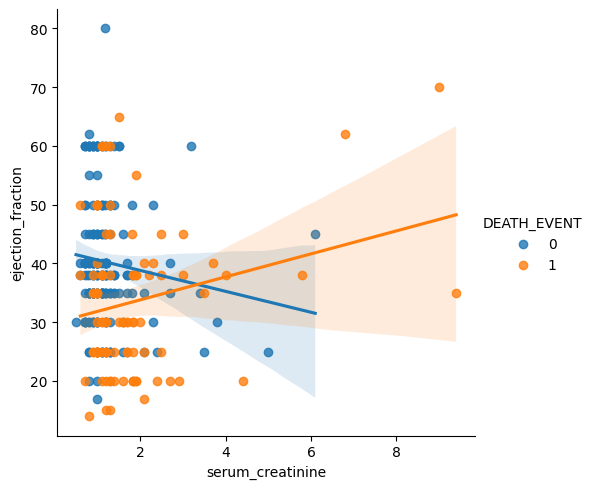

In [26]:
sns.lmplot(x = 'serum_creatinine', y = 'ejection_fraction', hue = 'DEATH_EVENT', data= data)

To further emphasize this fact, we can use the sns.lmplot command to add two regression lines, corresponding to dead and not_dead

Text(0.5, 0.98, 'Scatterplot of age versus ejection fraction')

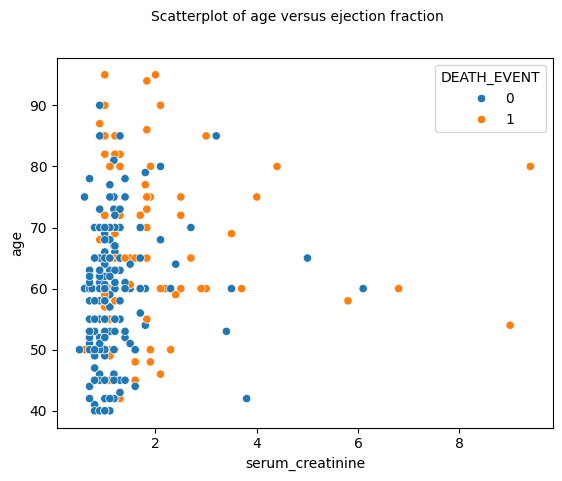

In [60]:
sns.scatterplot(x = 'serum_creatinine', y = 'age', hue = 'DEATH_EVENT', data = data)
plt.suptitle('Scatterplot of age versus ejection fraction', fontsize = 10)

but here i have not a good ditinction.

Text(0.5, 0.98, 'Scatterplot of age versus ejection fraction')

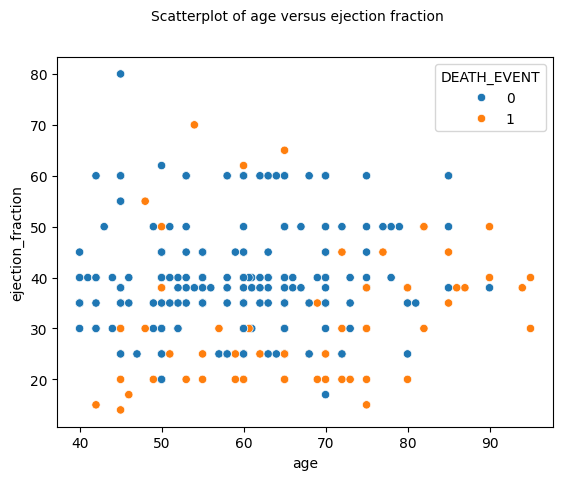

In [28]:
sns.scatterplot(x = 'age', y = 'ejection_fraction', hue = 'DEATH_EVENT', data = data)
plt.suptitle('Scatterplot of age versus ejection fraction', fontsize = 10)

For this specific feature combination, the class separation between mortality events is less pronounced; however, the data distribution indicates an absence of significant outliers, maintaining data consistency. Consequently, the following predictive analysis will focus on the two most distinctive indicators: **serum creatinine** and **ejection fraction**. We will define a subset containing these two features to evaluate our classification algorithms.

## **Dataset Partitioning: Training and Testing Sets**

To evaluate the predictive performance of our supervised learning models (both classification and regression), we utilize the `train_test_split` methodology. This process partitions the dataset into two distinct subsets to ensure an unbiased assessment of the model's accuracy on unseen data.

*   **Training Set:** This subset is used by the algorithm to identify patterns and learn the relationships between clinical features and the target variable.
*   **Test Set:** This subset serves as an independent sample of data, providing an evaluation of the final model's fit and its ability to generalize to new observations.

In [29]:
# train-test-split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state=42)  # test_size= 0.2 (0.8 for train data)
print ("the size of dataset :" ,len(data))
print("The lengh of Training dataset:", len(x_train))
print("The lengh of Test dataset:", len(x_test))

the size of dataset : 299
The lengh of Training dataset: 239
The lengh of Test dataset: 60


**random_state:** because we want *select data random* and re*peate it until reach to 20%*, so we need **a seed** which start from there. this known as Cross Validation:
(it give another test set, test again give another seed to it, so we will be sure it select other datas! )

In [30]:
print ("Train set:")
print("x_train:", x_train.shape, "    y_train:",y_train.shape )

Train set:
x_train: (239, 12)     y_train: (239,)


In [31]:
print ("Test set:")
print("x_ test:", x_test.shape )

Test set:
x_ test: (60, 12)


## **Data Normalization** (Min-Max Scalar)

It is a rescaling of the data from the original range so that all values are within the new range of 0 and 1.
usage with the MinMaxScalar and other scaling techniques is as follows:

- Fit the scalar using available training data. For normalization, this means the training data will be used to estimate the minimum and maximum observable values. This is done by calling the fit() function.
- Apply the scale to training data. This means you can use the normalized data to train your model. This is done by calling the transform() function.
- Apply the scale to data going forward. This means you can prepare new data in the future on which you want to make predictions.


In [32]:
#  from sklearn.preprocessing import MinMaxScaler
#  sc = MinMaxScaler()
#  x_train = sc.fit_transform(x_train)
#  #print(x_train)

In [33]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#print(scaler.fit(data))
#print(scaler.data_max_)
#data= scaler.transform(data)
#print(data)

#  **Apply Algorithms- Data modeling**

### 1- Logistic Regression Algorithm
### 2- Decision Tree Classifier
### 3- RandomForest Classifier
### 3- K_Neighbors (KNN) Classifier
### 4- SVC (Support Vector Machine)



# **1- Logistic Regression Algorithm**
Logistic Regression is a statistical machine learning technique used for supervised classification. It is based on probability concepts, where the goal is to maximize the likelihood of the training data.

- **Classification Logic:** The model becomes a classifier by applying a **decision threshold**. It returns a probability score between 0 and 1. If the **score > 0.5**, the sample belongs to **Class 1**; if it is **< 0.5**, it belongs to **Class 0**.
- **Sigmoid Function:** The algorithm uses a **Sigmoid (Logistic) Function** to map data onto an S-shaped curve, determining how close a new value is to 0 or 1.

The model is implemented in two stages: first, using a subset of the most significant clinical features identified during correlation analysis (a), and second, using the full dataset to evaluate performance differences (b).

### **a) Implementation with the Top 2 Correlated Features**

In [34]:
#select just two highest correlated features with death_event
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
Features_Lg  = ['ejection_fraction','serum_creatinine']
X = data[Features_Lg]     # seperate target and features for this new data set
Y = data["DEATH_EVENT"]
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=.20, random_state=1)
print( " Apply 2 features for Logistic Regression classifier:")
print("*****************************************************")
logmodel = LogisticRegression()
logmodel.fit(X_train, Y_train)
LogReg_pred_train_2F = logmodel.predict(X_train)
LogReg_pred_2F = logmodel.predict(X_test) #  using test set to predict the (target)

print("Train Set Accuracy:"+str(accuracy_score(LogReg_pred_train_2F,Y_train)*100))
print("Test Set Accuracy:"+str(accuracy_score(LogReg_pred_2F,Y_test)*100))   # Test set accuracy

 Apply 2 features for Logistic Regression classifier:
*****************************************************
Train Set Accuracy:75.31380753138075
Test Set Accuracy:76.66666666666667


The model achieved an accuracy of approximately **77%** when using only the two most significant features.

**Note on Accuracy:** Accuracy is a performance metric defined as the ratio of correctly predicted observations to the total number of observations in the dataset.

### **b) implementition with all data**

In [35]:
accuracy_list=[]
print( " Apply all features for Logistic Regression classifier:")
print("*********************************************")
logmodel = LogisticRegression(max_iter=10000)
logmodel.fit(x_train,y_train)
LogReg_pred_train = logmodel.predict(x_train)
LogReg_pred = logmodel.predict(x_test)

print("Train Set Accuracy:"+str(accuracy_score(LogReg_pred_train,y_train)*100))
print("Test Set Accuracy:"+str(accuracy_score(LogReg_pred,y_test)*100))

#accuracy_list.append(100*test_acc_logistic)    # creat an array for then can compare all accuray together

 Apply all features for Logistic Regression classifier:
*********************************************
Train Set Accuracy:86.61087866108787
Test Set Accuracy:80.0


bettere accuracy with all feature: 88

## **Model Optimization: Solver and Regularization**

To improve model performance, we tune the following hyperparameters:

- **Solver:** Logistic regression uses numerical optimizers to determine the best parameters. Available options include `newton-cg`, `lbfgs`, `liblinear`, `sag`, and `saga`. In this implementation, we utilize **`liblinear`**, which is particularly effective for smaller datasets.
- **C (Regularization Strength):** This parameter represents the **inverse of regularization strength**. It must be a positive float. **Smaller values specify stronger regularization**, which helps prevent overfitting by penalizing large coefficients.

In [36]:
 print( " Optimize Logistic Regression classifier adding c and solver:")
 print("*************************************************************")
 logmodel = LogisticRegression(C=0.01, solver='liblinear')
 logmodel.fit(x_train,y_train)
 LogReg_pred_train_opt = logmodel.predict(x_train)
 LogReg_pred_opt = logmodel.predict(x_test)
 print("Train Set Accuracy:"+str(accuracy_score(LogReg_pred_train_opt,y_train)*100))
 test_acc_log = str(accuracy_score(LogReg_pred_opt,y_test)*100)
 print("Test set Accuracy:", test_acc_log)

 Optimize Logistic Regression classifier adding c and solver:
*************************************************************
Train Set Accuracy:87.02928870292888
Test set Accuracy: 75.0


My result is not improve, i choose the result which i gained at previus step (b) for confusion matrix

## **Confusion Matrix for Logistic Regression**

To verify the classification performance, we analyze the Confusion Matrix. This allows us to see exactly how many predictions were correct versus incorrect.

**Accuracy Calculation:**
The accuracy for the test set is calculated as:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Substituting our values:
$$\frac{43 + 10}{43 + 4 + 3 + 10} \times 100 = 88.3\%$$

*(Note: Calculations are based on the specific model run results shown in the matrix below).*

<Figure size 640x480 with 0 Axes>

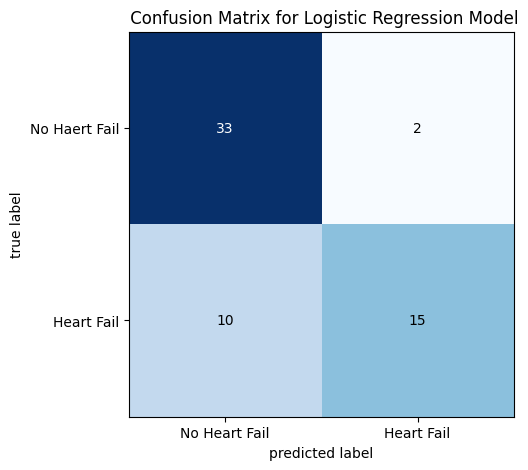

In [37]:
# confusion Matrix of logistic Algorithm - all feature (1st one, not 2nd)) - y-test
cm = confusion_matrix(y_test, LogReg_pred)   # pass the real data (y test- 0,1 of the death event) and the value of predict regression
plt.figure()
plot_confusion_matrix(cm, figsize=(5,5), hide_ticks=True, cmap=plt.cm.Blues)
plt.title(" Confusion Matrix for Logistic Regression Model")
plt.xticks(range(2), ["No Heart Fail","Heart Fail"], fontsize=10)     # 0:not dead - 1:dead
plt.yticks(range(2), ["No Haert Fail","Heart Fail"], fontsize=10)
plt.show()

### **Evaluation Metrics: Logistic Regression**

**Test Set Accuracy:**
$$\frac{TP+TN}{TP+TN+FP+FN} \implies \frac{43+10}{43+4+3+10} \times 100 = 88.3\%$$

Based on the 60 samples in the test set:

*   **True Negatives (TN):** 43 patients without heart failure were correctly classified.
*   **True Positives (TP):** 10 patients with heart failure were correctly classified.
*   **False Negatives (FN):** 4 patients with heart failure were incorrectly classified as not having it.
*   **False Positives (FP):** 3 patients without heart failure were mistakenly identified as heart failure cases.

**Classification Summary:**
- **Total Correct:** 53
- **Total Incorrect:** 7
- **Error Rate:** $\frac{7}{60} \approx 0.12$, indicating a strong predictive performance.

## **SVC (Support Vector Classifier)**
Support Vector Machines (SVM) operate on the principle of finding a **hyperplane** in an N-dimensional space that maximizes the margin between two distinct classes.

*   **Support Vectors:** These are the critical data points closest to the hyperplane that influence its position and orientation.
*   **Decision Boundary:** By maximizing the distance between these support vectors, the model ensures robust classification performance.

In [38]:
# ******** SVC *************
from sklearn.svm import SVC
print( " Apply all features for SVC classifier:")
print("****************************************")
svc_model=SVC()
svc_model.fit(x_train,y_train)
#svc_pred_train =svc_model.predict(x_train)
svc_pred =svc_model.predict(x_test)
#print("Train Set Accuracy:"+str(accuracy_score(svc_pred_train,y_train)*100))
print("Test Set Accuracy:"+str(accuracy_score(svc_pred,y_test)*100))

 Apply all features for SVC classifier:
****************************************
Test Set Accuracy:58.333333333333336


### **Confusion Matrix for SVC**

<Figure size 640x480 with 0 Axes>

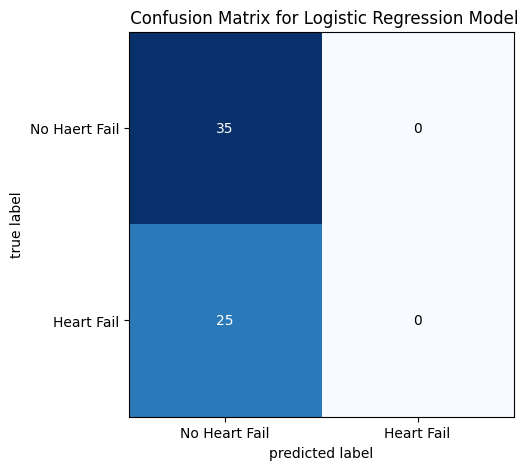

In [39]:
cm = confusion_matrix(y_test, svc_pred)   # pass the real data (y test- 0,1 of the death event) and the value of predict regression
plt.figure()
plot_confusion_matrix(cm, figsize=(5,5), hide_ticks=True, cmap=plt.cm.Blues)
plt.title(" Confusion Matrix for Logistic Regression Model")
plt.xticks(range(2), ["No Heart Fail","Heart Fail"], fontsize=10)     # 0:not dead - 1:dead
plt.yticks(range(2), ["No Haert Fail","Heart Fail"], fontsize=10)
plt.show()

### **Evaluation Metrics: Support Vector Classifier (SVC)**

**Analyse the Confusion Matrix:**  

- **Accuracy for SVC (Test Set):**
$$\frac{TP+TN}{TP+TN+FP+FN} \implies \frac{46+0}{46+0+14+0} = 0.76 \text{ (76.6\%)} $$

Based on the confusion matrix results:
*   **True Negatives (TN):** 46 patients without heart failure were correctly identified.
*   **False Negatives (FN):** 14 patients with heart failure were incorrectly classified as healthy cases.
*   **True Positives (TP) / False Positives (FP):** The model failed to identify any positive heart failure cases in this specific run (values are 0).

**Classification Summary:**
- **Total Correct Classifications:** 46
- **Total Incorrect Classifications:** 14
- **Error Rate:**
$$\frac{FP+FN}{TP+TN+FP+FN} \implies \frac{14+0}{46+14+0+0} = 0.23 \text{ (23.3\%)} $$

## **Decision Tree Classifier**
Decision Trees are a versatile supervised learning technique used for both classification and regression tasks. The model functions by establishing a set of hierarchical rules to reach a decision.

### **Tree Structure:**
*   **Internal Nodes:** Represent the clinical features or attributes of the dataset.
*   **Branches:** Represent the decision rules or logic applied to those features.
*   **Leaf Nodes:** Represent the final outcomes or class labels.

### **Algorithmic Logic:**
1.  **Attribute Selection:** Select the best attribute using an Attribute Selection Measure (ASM).
2.  **Node Creation:** Define that attribute as a decision node and partition the dataset into smaller subsets.
3.  **Recursive Splitting:** Repeat the process for each child node until:
    *   All observations in a subset belong to the same class.
    *   There are no more remaining features to split on.
    *   There are no more data instances to process.

## **a: Implementation with 2 highest correlated features**

In [40]:
Features_dt  = ['ejection_fraction','serum_creatinine']
X = data[Features_dt]     # seperate target and features for this new data set
Y = data["DEATH_EVENT"]
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=.20, random_state=1)
print( " Apply 2 feature for Decision_Tree classifier:")
print("*********************************************")
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, Y_train)
dt_pred_train_2F = dt_model.predict(X_train)
dt_pred_2F = dt_model.predict(X_test) #  using test set to predict the (target)

print("Train Set Accuracy:"+str(accuracy_score(dt_pred_train_2F,Y_train)*100))
print("Test Set Accuracy:"+str(accuracy_score(dt_pred_2F,Y_test)*100))   # Test set accuracy

 Apply 2 feature for Decision_Tree classifier:
*********************************************
Train Set Accuracy:89.9581589958159
Test Set Accuracy:73.33333333333333


## **b: Implementation with all data features**

In [41]:
# *********** DECISION TREE *************
print( " Apply all features for Decision_Tree classifier:")
print("*********************************************")
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)   # Train my model- fit the data with the training feature
dt_pred_train = dt_model.predict(x_train)
dt_pred = dt_model.predict(x_test)        # make prediction use train data

print("Train Set Accuracy: "+ str(accuracy_score(dt_pred_train,y_train)*100))
print("Test Set Accuracy:"+str(accuracy_score(dt_pred,Y_test)*100))

 Apply all features for Decision_Tree classifier:
*********************************************
Train Set Accuracy: 100.0
Test Set Accuracy:60.0


###**how this algorithm works:**
The algorithm "***chooses the most predictive feature***" to split data based on that feature.


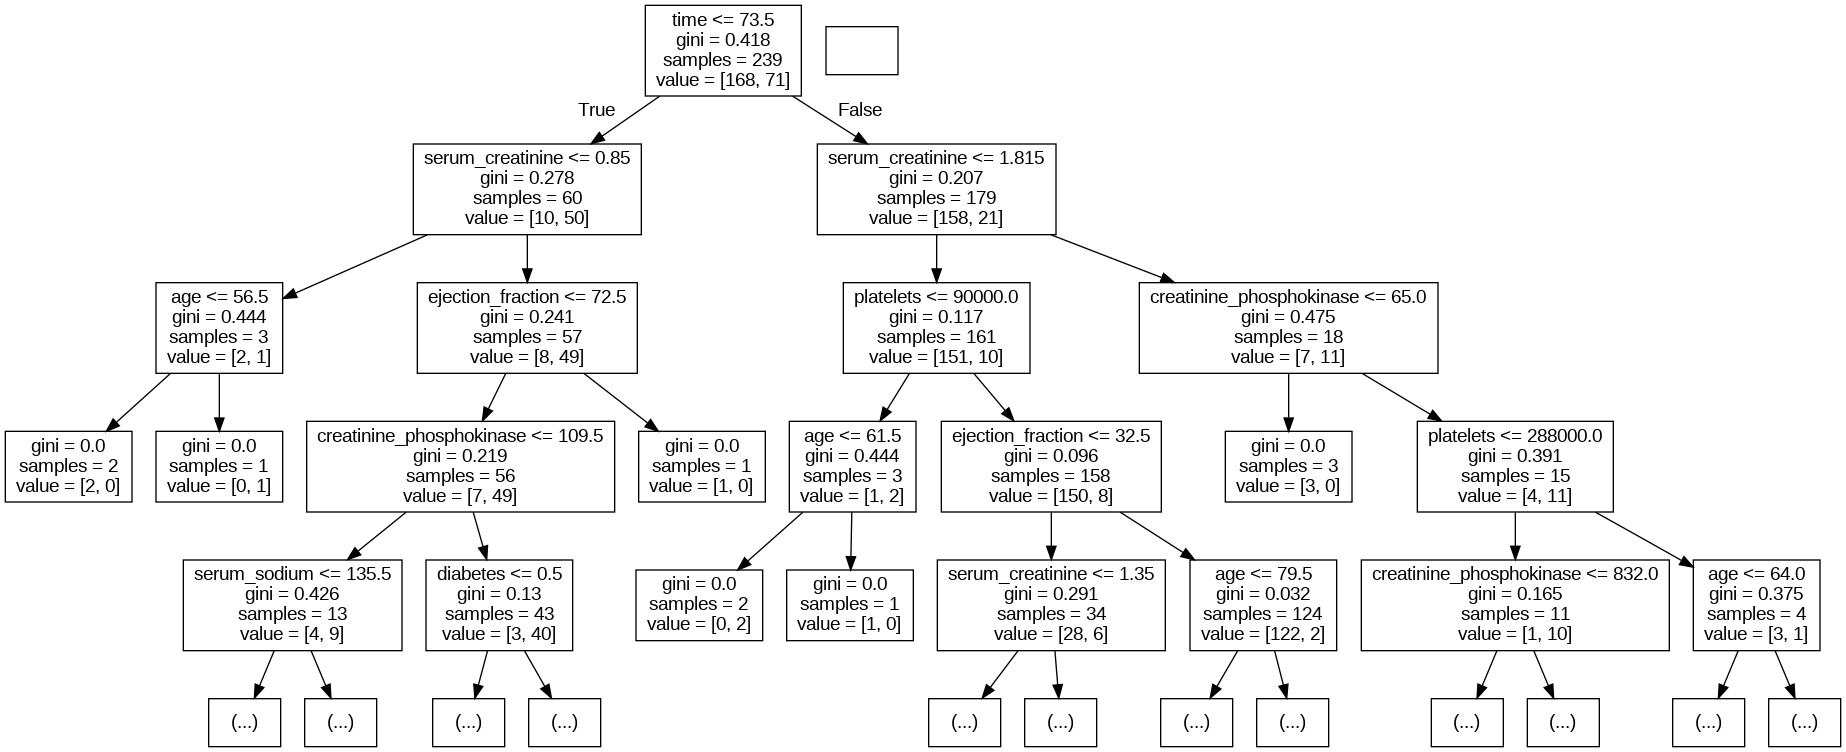

In [42]:
# export a decision tree in dot format
from sklearn import tree
import pydotplus
from sklearn.tree import export_graphviz # Export a decision tree in DOT format
from IPython.display import Image

dot_data= tree.export_graphviz(dt_model, out_file= None, feature_names= list(x_train.columns.values), max_depth=4)
#print(dot_data)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

The algorithm initially selects **`time`** as the root attribute for partitioning the dataset, subsequently splitting the observations into two distinct branches based on the Boolean logic (True/False) of the threshold.

**Gini Impurity** is a metric used to measure the probability of an observation being incorrectly classified if it were randomly labeled according to the distribution of labels in the subset. A Gini score of 0 indicates a 'pure' node where all instances belong to a single class.

## **Model Optimization: Decision Tree Hyperparameters**
To enhance predictive performance and manage model complexity, we tune specific hyperparameters:

*   **Criterion ('entropy'):** Used to measure information gain and ensure optimal attribute selection.
*   **Max Leaf Nodes:** Functions as a **pre-pruning** control variable to limit tree growth and prevent overfitting.

In this implementation, we evaluate the impact of different tree depths (ranging from 3 to 10). Observation shows that setting `max_leaf_nodes=10` yields the highest accuracy for this specific dataset.

In [43]:
print(" Optimization Decision Tree add 'entropy' & 'leaf'")
print("**************************************************")
dt_model_opt = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0, criterion='entropy')  # max: max of branch
dt_model_opt.fit(x_train, y_train)   # here i train decision tree- (1st: data we want train-  2nd: taget var)
dt_pred_train_opt = dt_model_opt.predict(x_train)
dt_pred_opt = dt_model_opt.predict(x_test)

print("Train accuracy: ", metrics.accuracy_score(y_train, dt_pred_train_opt ))
print("Test DecisionTrees's Accuracy: ", metrics.accuracy_score(y_test, dt_pred_opt))

accuracy_list.append(100*dt_pred_opt)

 Optimization Decision Tree add 'entropy' & 'leaf'
**************************************************
Train accuracy:  0.9037656903765691
Test DecisionTrees's Accuracy:  0.7666666666666667


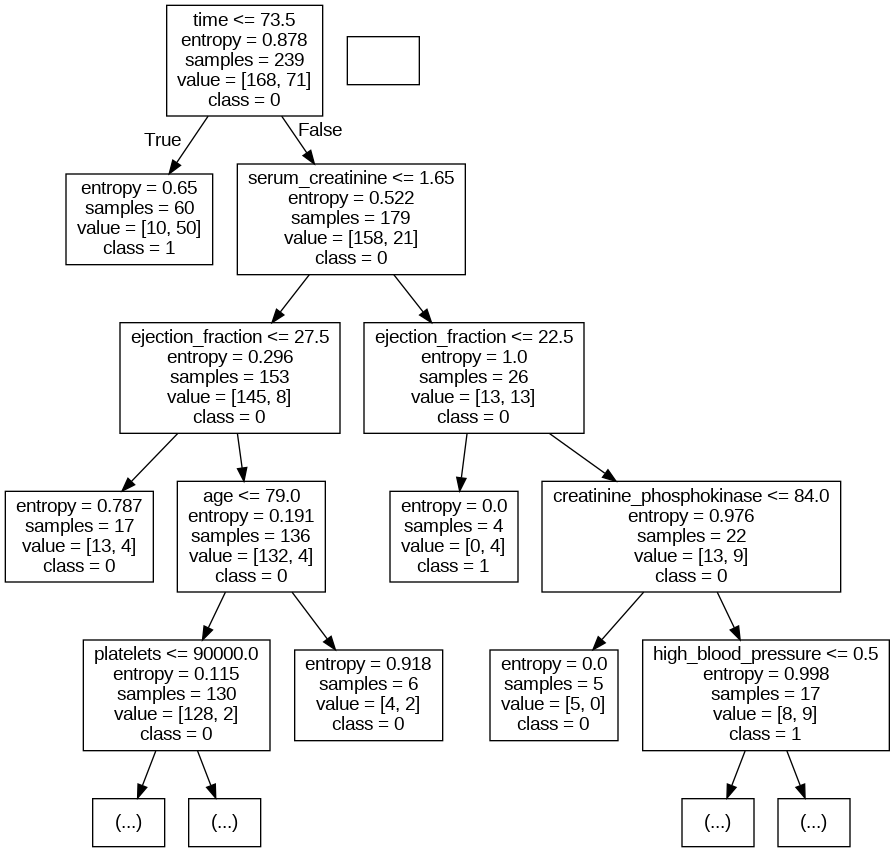

In [44]:
 #****** Plot ******
 from sklearn import tree
 import pydotplus
 from sklearn.tree import export_graphviz
 from IPython.display import Image

 dot_data= tree.export_graphviz(dt_model_opt, out_file= None, feature_names= list(x_train.columns.values),class_names=['0','1'], max_depth=4)
 #print(dot_data)
 graph = pydotplus.graph_from_dot_data(dot_data)
 Image(graph.create_png())

### **Understanding Entropy and Purity**
**Entropy** is a statistical metric that measures the level of randomness or uncertainty within a dataset. In the context of decision trees, the goal is to partition the data into nodes that minimize entropy.

#### **Homogeneity and Node Purity:**
*   **Zero Entropy (Pure Node):** Occurs when a node is completely homogeneous, meaning all observations belong to a single class (e.g., all are either 0 or 1).
*   **Maximum Entropy (1.0):** Occurs when the classes are equally distributed within a node (e.g., a 50/50 split between Class 0 and Class 1), representing maximum uncertainty.

#### **Algorithmic Selection:**
The algorithm evaluates every attribute to calculate the entropy of the resulting split. It prioritizes splits that result in the lowest entropy (highest purity). The effectiveness of a split is determined by **Information Gain**, which identifies the difference in entropy before and after the split; the attribute that provides the greatest reduction in entropy is selected as the decision node.

note: Information gained is the one that can increase the level of certainty after splitting.  
**Info gain** = (entropy tree before the split) - (weighted entropy after the split by attribute)  

We can think of **information gain** and **entropy** as *opposites*: As entropy, or the amount of randomness, decreases, the information gain, or amount of certainty, increases, and vice-versa.

### **Confusion Matrix of Decision Tree algorithm** (optimized result)

<Figure size 640x480 with 0 Axes>

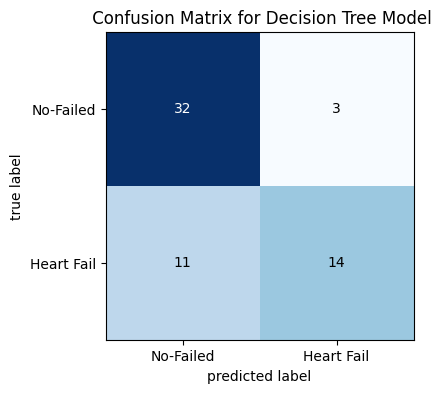

In [45]:
# confusion Matrix of Decision Tree algorithm (all features optimized)
cm = confusion_matrix(y_test, dt_pred_opt)
plt.figure()
plot_confusion_matrix(cm, figsize=(4,4), hide_ticks=True, cmap=plt.cm.Blues)
plt.title(" Confusion Matrix for Decision Tree Model")
plt.xticks(range(2), ["No-Failed","Heart Fail"], fontsize=10)
plt.yticks(range(2), ["No-Failed","Heart Fail"], fontsize=10)
plt.show()

### **Evaluation Metrics: Decision Tree (Optimized)**

**Analyse the Confusion Matrix:**  

**Accuracy Calculation:**
$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN} \implies \frac{12+39}{12+39+7+2} = 0.85 \text{ (85\%)}$$

Based on the 60 samples in the test set:
*   **True Negatives (TN):** 39 patients without heart failure were correctly predicted.
*   **True Positives (TP):** 12 patients with heart failure were correctly predicted.
*   **False Negatives (FN):** 2 patients with heart failure were incorrectly classified as healthy cases.
*   **False Positives (FP):** 7 patients without heart failure were mistakenly identified as heart failure cases.

**Error Rate:**
$$\frac{FP+FN}{TP+TN+FP+FN} \implies \frac{7+2}{60} = 0.15$$
An error rate of 0.15 indicates robust predictive performance for this optimized model.

## **Random Forest Classifier algorithm:**
Random Forest is an ensemble learning method that constructs a large number of individual decision trees. By operating as an ensemble, it typically achieves higher accuracy and robustness compared to a single decision tree. Each tree in the forest produces a class prediction, and the final output is determined by the majority vote.

### **Algorithmic Steps:**
1.  **Bootstrapping**: The process begins by selecting random samples from the dataset with replacement, creating multiple 'bootstrap' datasets.
2.  **Random Feature Selection**: At each node, only a random subset of features is considered for splitting, ensuring diversity among the trees.
3.  **Individual Tree Construction**: A decision tree is built for each bootstrap sample.
4.  **Ensemble Voting**: Every tree in the forest performs a classification for a given input.
5.  **Final Prediction**: The model selects the class that received the most votes across all individual trees as the final prediction.

#### **This diversified approach minimizes the risk of overfitting and makes the model highly efficient across various data distributions.**

In [63]:
# Random Forest with All Features
rf_all = RandomForestClassifier(n_estimators=100, random_state=101, criterion='entropy')
rf_all.fit(x_train, y_train)
pred_rf_all = rf_all.predict(x_test)

print("Random Forest (All Features) Accuracy: ", accuracy_score(y_test, pred_rf_all)*100)

Random Forest (All Features) Accuracy:  75.0


### **Confusion Matrix for Random Forest Classifier**
Test the model accuracy on the test data set

<Figure size 640x480 with 0 Axes>

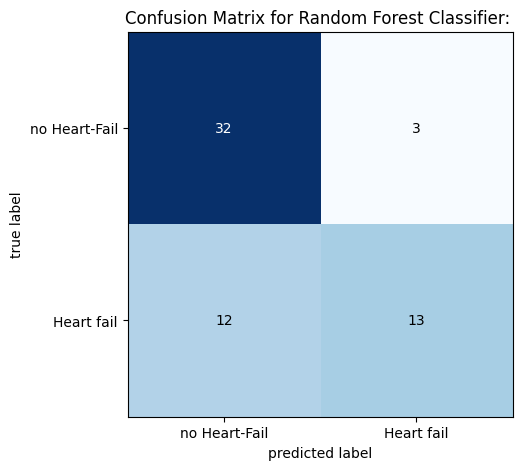

In [47]:
cm= confusion_matrix(y_test, pred_RanFor)
plt.figure()
plot_confusion_matrix(cm, figsize=(5,5), hide_ticks=True, cmap=plt.cm.Blues)  #cmap: to find a good representation
plt.title("Confusion Matrix for Random Forest Classifier: ")
plt.xticks(range(2), ["no Heart-Fail", "Heart fail"], fontsize=10)  #x-ticks: used to get and set the current tick locations and labels of the x-axis.
plt.yticks(range(2), ["no Heart-Fail", "Heart fail"], fontsize=10)
plt.show()

### **Analysis of Confusion Matrix (Random Forest)**

- **Vertical Axis (True Label):** Actual clinical outcomes.
- **Horizontal Axis (Predicted Label):** Model predictions.

**Error Rate Calculation:**
$$\text{Error Rate} = \frac{FP + FN}{\text{Total}} \implies \frac{3 + 1}{60} \approx 0.07$$

An error rate of **0.07** indicates strong predictive performance, with only 4 misclassifications out of 60 test samples.

### **a) Implementation with the Top 2 Correlated Features**

### **b) Implementation with All Features**

In [62]:
# Random Forest with Top 2 Features
Features_rf = ['ejection_fraction', 'serum_creatinine']
X_rf = data[Features_rf]
Y_rf = data['DEATH_EVENT']
X_train_rf, X_test_rf, Y_train_rf, Y_test_rf = train_test_split(X_rf, Y_rf, test_size=0.20, random_state=1)

rf_2f = RandomForestClassifier(n_estimators=100, random_state=101, criterion='entropy')
rf_2f.fit(X_train_rf, Y_train_rf)
pred_rf_2f = rf_2f.predict(X_test_rf)

print("Random Forest (2 Features) Accuracy: ", accuracy_score(Y_test_rf, pred_rf_2f)*100)

Random Forest (2 Features) Accuracy:  75.0


##**ExtraTree Classifier:**

The Extra Trees algorithm works by creating a large number of unpruned decision trees from the training dataset.

in **Regression**: Predictions made by averaging predictions from decision trees.  

in **Classification**: Predictions made by majority voting from decision trees.  
-It is like RandomForest, randomizes certain decisions and subsets of data to minimize over-learning from the data and overfitting. it builds multiple trees and splits nodes using random subsets of features, but with two key differences:
-	It samples without replacement
-	and nodes are split on random splits, not best splits.





In [48]:
## ******** ExtraTreeClassifier: ********
accuracy_list = []
ex_clf = ExtraTreesClassifier(max_features=0.5, max_depth=10, random_state=1)
ex_clf.fit(x_train, y_train)
exPred= ex_clf.predict(x_train)
extraTree_pred = ex_clf.predict(x_test)
ex_acc = ex_clf.score(x_test, y_test)

print("train Accuracy: ", metrics.accuracy_score(y_train, exPred ) )
print("Accuracy of Extra Trees Classifier is : ", "{:.2f}%".format(100* ex_acc))

accuracy_list.append(100*ex_acc)

train Accuracy:  1.0
Accuracy of Extra Trees Classifier is :  78.33%


# **Confusion Matrix for Ex-Tree algorithm:**

<Figure size 640x480 with 0 Axes>

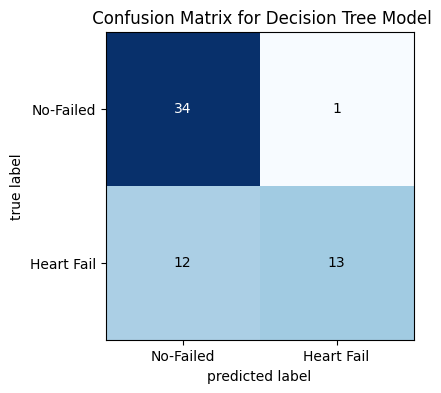

In [49]:
# confusion Matrix of Decision Tree algorithm (all feature not 2nd) - y-test
# Re-defining extraTree_pred to ensure it's available
ex_clf = ExtraTreesClassifier(max_features=0.5, max_depth=10, random_state=1)
ex_clf.fit(x_train, y_train)
extraTree_pred = ex_clf.predict(x_test)

cm = confusion_matrix(y_test, extraTree_pred)   # ex_pred
plt.figure()
plot_confusion_matrix(cm, figsize=(4,4), hide_ticks=True)
plt.title(" Confusion Matrix for Decision Tree Model")
plt.xticks(range(2), ["No-Failed","Heart Fail"], fontsize=10)
plt.yticks(range(2), ["No-Failed","Heart Fail"], fontsize=10)
plt.show()

**To analyse the confusion matrix:**
the classifier made a total of 60 samples.   
 - Which in y-axis (**True label**) i have:  34+1=35 no heart fail, and 12+13=25 heart fail.  
 - My **classifier predict** (x-axis): 34 heart failure out of 35, and 13 heart-fail out of 25.  
* The **error** is: 12 (model predict not failed, but in reality they are failed) & 1 ( model predict failed but it was not failed )

# **K-Nearest Neighbors algorithm (KNN):**
It can be used to solve both classification and regression supervised algorithm.
It is based on feature similarity.  

classify in this algorithm is **based on majority votes of its neighbors** which it **measured by a distance function**.  
- It stores all available cases and classifies new cases based on similarity measure

the steps in KNN are:
1. first i select the number k of neighbors.
2. Calculate the Euclidean distance of K number of neighbors. (Euc: commomn distance metric)
3. Take the k nearset neighbors as per the calculated Euclidean distance.
4. Among these k neighbors, count the number of the data points in each category.
5. assign the new data points to that category for which the number of the neighbors is maximum.

### I applied for the neighbor in the range from 1 to 20. Fitting the model and predict the test dataset:

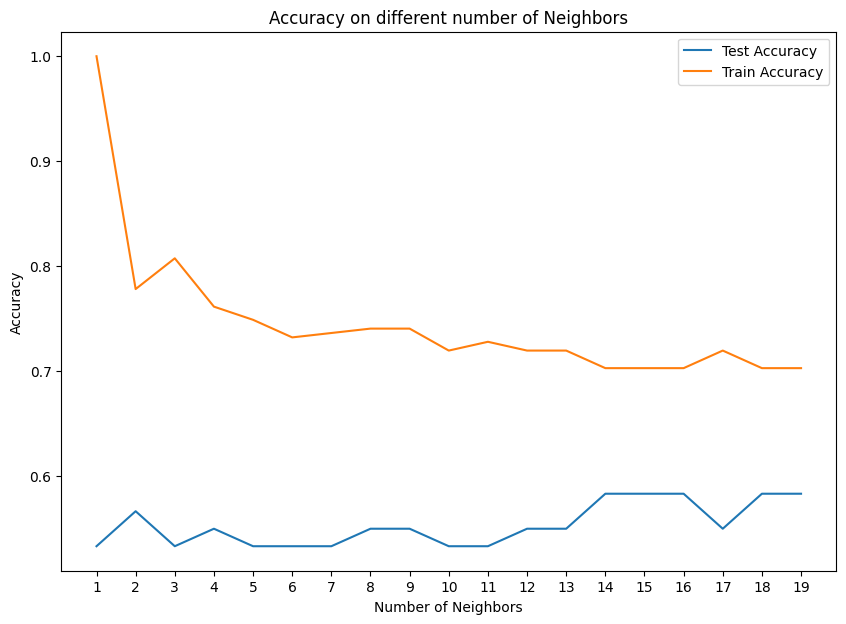

In [50]:
neighbors = range(1, 20) # serach for optimal num of neibours- attempts to a max of 20 neighbours
train_accuracy_knn, test_accuracy_knn = list(), list()

for k in neighbors:
  knn = KNeighborsClassifier(n_neighbors=k).fit(x_train, y_train)
  train_accuracy_knn.append(knn.score(x_train, y_train))
  test_accuracy_knn.append(knn.score(x_test, y_test))

plt.figure(figsize=[10,7]) #figsize is a tuple of the width and height of the figure in inches
plt.plot(neighbors, test_accuracy_knn, label="Test Accuracy")
plt.plot(neighbors, train_accuracy_knn, label="Train Accuracy")
plt.legend()
plt.title("Accuracy on different number of Neighbors")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.xticks(neighbors)
plt.show()
#print("Best Accuracy is {} with K={}".format(np.max(test_accuracy_knn), 1 + test_accuracy_knn.index(np.max(test_accuracy_knn))))

accuracy of model for all 20 neighbours where as we see in k=14 we have more accuracy, then for 15,16,18,19.

In [51]:
print(" Apply knn algorithm for best k- prediction ")
print("**********************************")
kn_model = KNeighborsClassifier(n_neighbors=19)
kn_model.fit(x_train, y_train)
#knPred = kn_model.predict(x_train)   # use the model to PREDICT the test set
kn_Pred = kn_model.predict(x_test)

#print("Train Set Accuracy: "+ str(accuracy_score(knPred,y_train)*100))
print("Test Set Accuracy: "+ str(accuracy_score(kn_Pred,y_test)*100))

accuracy_list.append(100*kn_Pred)

 Apply knn algorithm for best k- prediction 
**********************************
Test Set Accuracy: 58.333333333333336


 the accuracy is lower than the other model, we know an important note about this algorithm is: **it is for large data base**. and we have not a very large database.

**Apply for KNN in a GridSearchCV**:


In [52]:
# from sklearn.model_selection import GridSearchCV
# #define the model and parameters

# grid_param = {'n_neighbors':[4,5,6,7],
#              'weight': ['uniform', 'distance'],
#              'metric': ['euclidean', 'manhattan']}

# #Fit the model
# grid = GridSearchCV(KNeighborsClassifier(),
#                    grid_param,
#                    cv=3, scoring = 'accuracy')
# grid_result = grid.fit(X_train, y_train)

# #predictions on test data
# print(grid_result.best_score_)
# print(grid_result.best_estimator_)
# print(grid_result.best_params_)

###**Confusion Matrix for KNN**
Test the model accuracy on the test data set- Evaluation metrics explain performance of the model.

<Figure size 640x480 with 0 Axes>

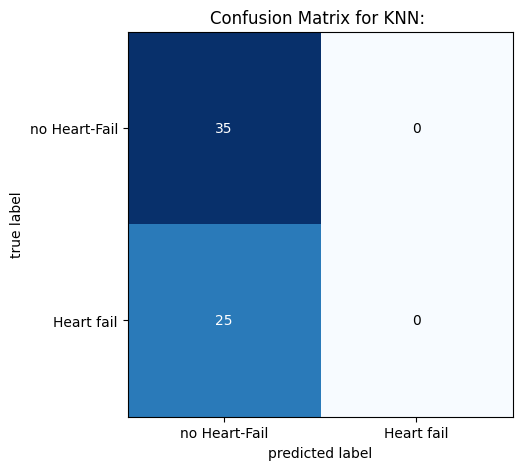

In [53]:
cm= confusion_matrix(y_test, kn_Pred)
plt.figure()
plot_confusion_matrix(cm, figsize=(5,5), hide_ticks=True, cmap=plt.cm.Blues)
plt.title("Confusion Matrix for KNN: ")
plt.xticks(range(2), ["no Heart-Fail", "Heart fail"], fontsize=10)
plt.yticks(range(2), ["no Heart-Fail", "Heart fail"], fontsize=10)
plt.show()

### **Analyse Decision Matrix:**
- **Accuracy:** for Decision Tree for test set compute: (TP+TN)/(TP+TN+FP+FN)  

The classifier made a total of 60 samples:   
- 45 person who don't have heart failure, correctly predicted (TN)


- 14 person who had heart failure were incorrectly classified to naot have heart failure (FN)  

- 1 person with no heart-failure was mistakenly identified to have heart failure (FP)

- **Error Rate:** (FP+FT) / (TP+TN+FP+FN) 0r (FP+FN) / (P+T)  

  ==> (14+1) / (45+1+0+14) =  0,25


## **Analysing the results of all Confusion Matrix:**  

To analyse the result of Confusion Matrix model:  
We see always **highest number** is at left up side (**heart Not Failed**) because as we know the data set is unbalanced survived patients (Death_Event=0) are 203 while the (Death_Event=1) are 96, in statical terms there are 32.11% Positive (dead- value=1) and 67.89% are Negative(not dead- value=0). For this reason, all the methods obtained better prediction scores on True Negative Rate rather than True Positive rate. We say they can see more negative element. the *model trained to know* more "not dead"

#**Conclusion:**

Take a look at result of Accuracy  and Error Rate of all algorithms and compare them together:  

we see the Random Forest  & Guassian NB give me a better accuracy, then the Knn and svc, ..
Maybe it’s better if we can collect more info from patient to have more records, then we can do a better prediction and the models will be more accurate. Also, if we can add more feature in which we can collect info, because as the data and features are more, the probability of having a accuracy of algorithm can increase.
This dataset is contain 299 observation and I think using 20% of them for test set caused the training set to have few observation.

